In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import joblib

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_excel("../data/raw/PET_PNP_REFP2_DC_NUS_MBBL_M.xls")

df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,NaN,Workbook Contents,NaN,NaN,NaN,NaN,NaN
1,NaN,U.S. Refinery Net Production,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Click worksheet name or tab at bottom for data,NaN,NaN,NaN,NaN,NaN
4,NaN,Worksheet Name,Description,# Of Series,Frequency,Latest Data for,NaN


In [3]:
df.shape

(15, 7)

In [4]:
excel_file = pd.ExcelFile("../data/raw/PET_PNP_REFP2_DC_NUS_MBBL_M.xls")

excel_file.sheet_names

['Contents', 'Data 1']

In [5]:
df = pd.read_excel(
    "../data/raw/PET_PNP_REFP2_DC_NUS_MBBL_M.xls",
    sheet_name="Data 1"
)

In [6]:
df.head()

,Back to Contents,Data 1: U.S. Refinery Net Production,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52,Unnamed: 53,Unnamed: 54,Unnamed: 55,Unnamed: 56
0,Sourcekey,MTTRX_NUS_1,M_EPL0_YPY_NUS_MBBL,M_EPL2_YPY_NUS_MBBL,MENRX_NUS_1,MPARX_NUS_1,MBURX_NUS_1,MIIRX_NUS_1,M_EPLOLE_YPY_NUS_MBBL,MEYRX_NUS_1,...,MWXRX_NUS_1,MCKRX_NUS_1,MCMRX_NUS_1,MCORX_NUS_1,MAPRX_NUS_1,MSGRX_NUS_1,MMSRX_NUS_1,MMFRX_NUS_1,MMNRX_NUS_1,MPGRX_NUS_1
1,Date,U.S. Refinery Net Production of Crude Oil and ...,U.S. Refinery Net Production of Hydrocarbon Ga...,U.S. Refinery Net Production of Natural Gas Li...,U.S. Refinery Net Production of Ethane (Thousa...,U.S. Refinery Net Production of Propane (Thous...,U.S. Refinery Net Production of Normal Butane ...,U.S. Refinery Net Production of Isobutane (Tho...,U.S. Refinery Net Production of Refinery Olefi...,U.S. Refinery Net Production of Ethylene (Thou...,...,U.S. Refinery Net Production of Waxes (Thousan...,U.S. Refinery Net Production of Petroleum Coke...,U.S. Refinery Net Production of Petroleum Coke...,U.S. Refinery Net Production of Petroleum Coke...,U.S. Refinery Net Production of Asphalt and Ro...,U.S. Refinery Net Production of Still Gas (Tho...,U.S. Refinery Net Production of Miscellaneous ...,U.S. Refinery Net Production of Miscellaneous ...,U.S. Refinery Net Production of Miscellaneous ...,U.S. Refinery Processing Gain (Thousand Barrels)
2,1993-01-15 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1993-02-15 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1993-03-15 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.shape

(401, 57)

In [8]:
# Make the second row the column names
df.columns = df.iloc[1]

# Remove the first two metadata rows
df = df.iloc[2:].reset_index(drop=True)

# Check the result
print(df.shape)
df.head()

(399, 57)


1,Date,U.S. Refinery Net Production of Crude Oil and Petroleum Products (Thousand Barrels),U.S. Refinery Net Production of Hydrocarbon Gas Liquids (Thousand Barrels),U.S. Refinery Net Production of Natural Gas Liquids (Thousand Barrels),U.S. Refinery Net Production of Ethane (Thousand Barrels),U.S. Refinery Net Production of Propane (Thousand Barrels),U.S. Refinery Net Production of Normal Butane (Thousand Barrels),U.S. Refinery Net Production of Isobutane (Thousand Barrels),U.S. Refinery Net Production of Refinery Olefins (Thousand Barrels),U.S. Refinery Net Production of Ethylene (Thousand Barrels),...,U.S. Refinery Net Production of Waxes (Thousand Barrels),U.S. Refinery Net Production of Petroleum Coke (Thousand Barrels),U.S. Refinery Net Production of Petroleum Coke Marketable (Thousand Barrels),U.S. Refinery Net Production of Petroleum Coke Catalyst (Thousand Barrels),U.S. Refinery Net Production of Asphalt and Road Oil (Thousand Barrels),U.S. Refinery Net Production of Still Gas (Thousand Barrels),U.S. Refinery Net Production of Miscellaneous Petroleum Products (Thousand Barrels),U.S. Refinery Net Production of Miscellaneous Petroleum Products for Fuel Use (Thousand Barrels),U.S. Refinery Net Production of Miscellaneous Petroleum Products for Nonfuel Use (Thousand Barrels),U.S. Refinery Processing Gain (Thousand Barrels)
0,1993-01-15 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1993-02-15 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1993-03-15 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1993-04-15 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1993-05-15 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
missing = df.isnull().sum().sort_values()

missing

1
Date                                                                                                           0
U.S. Refinery Net Production of Commercial Kerosene-Type Jet Fuel (Thousand Barrels)                           0
U.S. Refinery Net Production of Military Kerosene-Type Jet Fuel (Thousand Barrels)                             0
U.S. Refinery Net Production of Naphthenic Lubricants (Thousand Barrels)                                       0
U.S. Refinery Net Production of Paraffinic Lubricants (Thousand Barrels)                                       0
U.S. Refinery Net Production of Isobutane (Thousand Barrels)                                                 144
U.S. Refinery Net Production of Normal Butane (Thousand Barrels)                                             144
U.S. Refinery Net Production of Crude Oil and Petroleum Products (Thousand Barrels)                          144
U.S. Refinery Net Production of Reformulated Motor Gasoline with Fuel ALcohol (Thousand Barrel

In [10]:
missing.head(20)

1
Date                                                                                                  0
U.S. Refinery Net Production of Commercial Kerosene-Type Jet Fuel (Thousand Barrels)                  0
U.S. Refinery Net Production of Military Kerosene-Type Jet Fuel (Thousand Barrels)                    0
U.S. Refinery Net Production of Naphthenic Lubricants (Thousand Barrels)                              0
U.S. Refinery Net Production of Paraffinic Lubricants (Thousand Barrels)                              0
U.S. Refinery Net Production of Isobutane (Thousand Barrels)                                        144
U.S. Refinery Net Production of Normal Butane (Thousand Barrels)                                    144
U.S. Refinery Net Production of Crude Oil and Petroleum Products (Thousand Barrels)                 144
U.S. Refinery Net Production of Reformulated Motor Gasoline with Fuel ALcohol (Thousand Barrels)    144
U.S. Refinery Net Production of Conventional Motor Gasoline (T

In [11]:
target = "U.S. Refinery Net Production of Finished Motor Gasoline (Thousand Barrels)"

df[target].isnull().sum()

np.int64(144)

In [12]:
df[["Date", target]].head(160)

1,Date,U.S. Refinery Net Production of Finished Motor Gasoline (Thousand Barrels)
0,1993-01-15 00:00:00,NaN
1,1993-02-15 00:00:00,NaN
2,1993-03-15 00:00:00,NaN
3,1993-04-15 00:00:00,NaN
4,1993-05-15 00:00:00,NaN
...,...,...
155,2005-12-15 00:00:00,192838
156,2006-01-15 00:00:00,186091
157,2006-02-15 00:00:00,160774
158,2006-03-15 00:00:00,169301


In [13]:
prophet_df = df[["Date", target]].copy()

prophet_df.columns = ["ds", "y"]

prophet_df = prophet_df.dropna()

prophet_df.head()

,ds,y
144,2005-01-15 00:00:00,189820
145,2005-02-15 00:00:00,169834
146,2005-03-15 00:00:00,181784
147,2005-04-15 00:00:00,191685
148,2005-05-15 00:00:00,194763


In [14]:
prophet_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255 entries, 144 to 398
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ds      255 non-null    object
 1   y       255 non-null    object
dtypes: object(2)
memory usage: 4.1+ KB


In [15]:
prophet_df.head()

,ds,y
144,2005-01-15 00:00:00,189820
145,2005-02-15 00:00:00,169834
146,2005-03-15 00:00:00,181784
147,2005-04-15 00:00:00,191685
148,2005-05-15 00:00:00,194763


In [16]:
prophet_df.describe()

,ds,y
count,255,255
unique,255,255
top,2005-01-15 00:00:00,189820
freq,1,1


In [17]:
# Convert Date to datetime
prophet_df["ds"] = pd.to_datetime(prophet_df["ds"])

# Convert Production to numeric
prophet_df["y"] = pd.to_numeric(prophet_df["y"])

# Verify data types
prophet_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255 entries, 144 to 398
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      255 non-null    datetime64[us]
 1   y       255 non-null    int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 4.1 KB


In [18]:
prophet_df.describe()

,ds,y
count,255,255.000000
mean,2015-08-15 12:02:49.411764,76825.815686
min,2005-01-15 00:00:00,33946.000000
25%,2010-04-30 00:00:00,44098.500000
50%,2015-08-15 00:00:00,52679.000000
75%,2020-11-30 00:00:00,99349.500000
max,2026-03-15 00:00:00,194763.000000
std,NaN,45211.253072


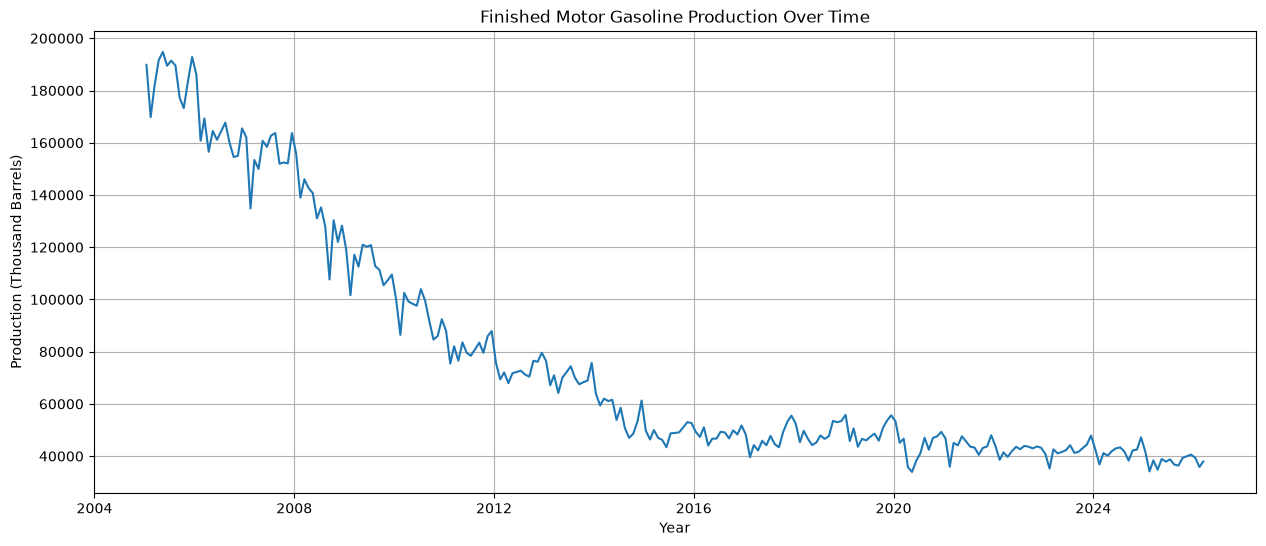

In [19]:
plt.figure(figsize=(15,6))

plt.plot(prophet_df["ds"], prophet_df["y"])

plt.title("Finished Motor Gasoline Production Over Time")

plt.xlabel("Year")

plt.ylabel("Production (Thousand Barrels)")

plt.grid(True)

plt.show()

In [20]:
train = prophet_df.iloc[:-24].copy()
test = prophet_df.iloc[-24:].copy()

print(f"Training rows : {len(train)}")
print(f"Testing rows  : {len(test)}")

train.tail()

Training rows : 231
Testing rows  : 24


,ds,y
370,2023-11-15,44450
371,2023-12-15,47880
372,2024-01-15,42645
373,2024-02-15,36799
374,2024-03-15,41135


In [21]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.95
)

In [22]:
model.fit(train)

16:12:24 - cmdstanpy - INFO - Chain [1] start processing
16:12:25 - cmdstanpy - INFO - Chain [1] done processing


In [23]:
future_test = test[["ds"]].copy()

forecast_test = model.predict(future_test)

forecast_test[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].head()

,ds,yhat,yhat_lower,yhat_upper
0,2024-04-15,38503.933837,29632.991883,48047.762183
1,2024-05-15,40900.333920,32024.570963,50313.498859
2,2024-06-15,40287.187914,30517.130644,49112.155084
3,2024-07-15,43268.847336,33952.279172,52365.241623
4,2024-08-15,41804.263987,31887.051288,51092.509461


In [24]:
prediction = forecast_test["yhat"].values
actual = test["y"].values

In [25]:
mae = mean_absolute_error(actual, prediction)

rmse = mean_squared_error(
    actual,
    prediction,
    squared=False
)

mape = mean_absolute_percentage_error(
    actual,
    prediction
)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape*100:.2f}%")

TypeError: got an unexpected keyword argument 'squared'

In [26]:
import sklearn
print(sklearn.__version__)

1.9.0


In [27]:
import numpy as np

mae = mean_absolute_error(actual, prediction)

mse = mean_squared_error(actual, prediction)

rmse = np.sqrt(mse)

mape = mean_absolute_percentage_error(actual, prediction)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape*100:.2f}%")

MAE  : 2028.28
MSE  : 6731737.81
RMSE : 2594.56
MAPE : 5.27%


In [28]:
comparison = pd.DataFrame({
    "Date": test["ds"].values,
    "Actual": actual,
    "Predicted": prediction
})

comparison.head(10)

,Date,Actual,Predicted
0,2024-04-15,40199,38503.933837
1,2024-05-15,41903,40900.333920
2,2024-06-15,43001,40287.187914
3,2024-07-15,43350,43268.847336
4,2024-08-15,41775,41804.263987
5,2024-09-15,38300,36645.042738
6,2024-10-15,42212,42974.210786
7,2024-11-15,42513,43459.020753
8,2024-12-15,47186,48426.469286
9,2025-01-15,41728,42739.515850


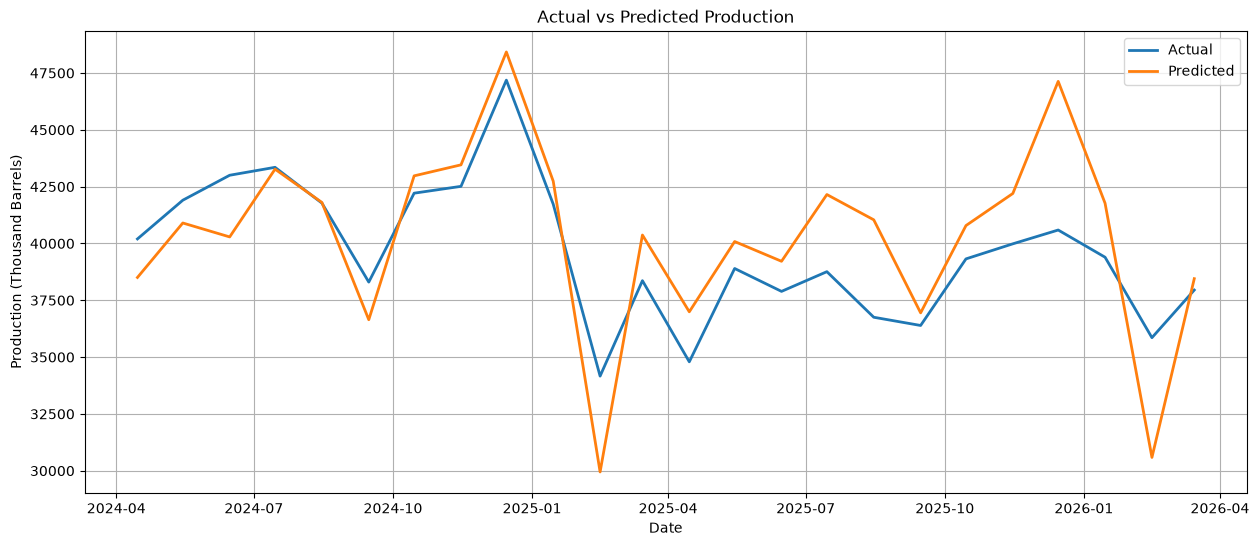

In [29]:
plt.figure(figsize=(15,6))

plt.plot(
    comparison["Date"],
    comparison["Actual"],
    label="Actual",
    linewidth=2
)

plt.plot(
    comparison["Date"],
    comparison["Predicted"],
    label="Predicted",
    linewidth=2
)

plt.title("Actual vs Predicted Production")

plt.xlabel("Date")

plt.ylabel("Production (Thousand Barrels)")

plt.legend()

plt.grid(True)

plt.show()

In [30]:
future = model.make_future_dataframe(
    periods=12,
    freq="MS"
)

future.tail()

,ds
238,2024-11-01
239,2024-12-01
240,2025-01-01
241,2025-02-01
242,2025-03-01


In [31]:
forecast = model.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
238,2024-11-01,41887.530930,41892.447125,61502.854521,41107.193451,42658.307089,10316.599069,10316.599069,10316.599069,10316.599069,10316.599069,10316.599069,0.0,0.0,0.0,52204.129998
239,2024-12-01,41806.290154,41813.709601,60402.588636,40883.754770,42698.989212,9221.205227,9221.205227,9221.205227,9221.205227,9221.205227,9221.205227,0.0,0.0,0.0,51027.495381
240,2025-01-01,41722.341352,54765.427354,73144.844978,40650.407681,42731.956797,22504.111434,22504.111434,22504.111434,22504.111434,22504.111434,22504.111434,0.0,0.0,0.0,64226.452786
241,2025-02-01,41638.392550,70024.116842,88719.515991,40401.427287,42800.029801,37234.885138,37234.885138,37234.885138,37234.885138,37234.885138,37234.885138,0.0,0.0,0.0,78873.277688
242,2025-03-01,41562.567826,-27147.998688,-9211.127448,40180.172099,42833.727611,-59894.724603,-59894.724603,-59894.724603,-59894.724603,-59894.724603,-59894.724603,0.0,0.0,0.0,-18332.156777


In [32]:
forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail(12)

,ds,yhat,yhat_lower,yhat_upper
231,2024-04-01,36101.804276,27102.351106,45472.242887
232,2024-05-01,56680.325000,47222.225259,66605.540948
233,2024-06-01,39639.401825,29734.712100,48961.520477
234,2024-07-01,44589.291490,35355.839856,54050.028563
235,2024-08-01,56935.909992,47561.884401,66512.344755
236,2024-09-01,61602.943989,51884.770919,71362.040290
237,2024-10-01,-19922.987092,-29274.835219,-10479.042915
238,2024-11-01,52204.129998,41892.447125,61502.854521
239,2024-12-01,51027.495381,41813.709601,60402.588636
240,2025-01-01,64226.452786,54765.427354,73144.844978


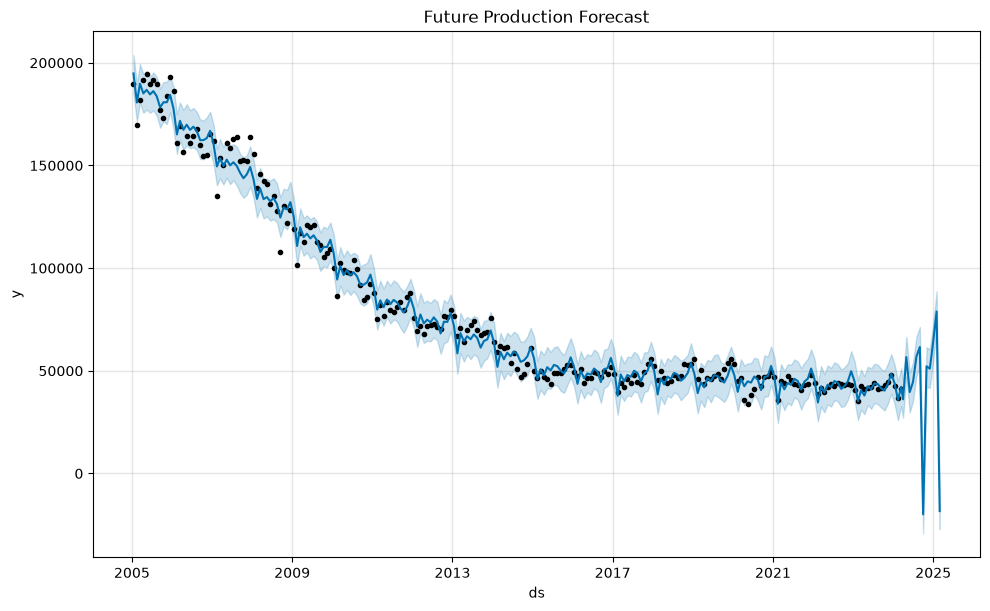

In [33]:
fig = model.plot(forecast)

plt.title("Future Production Forecast")

plt.show()

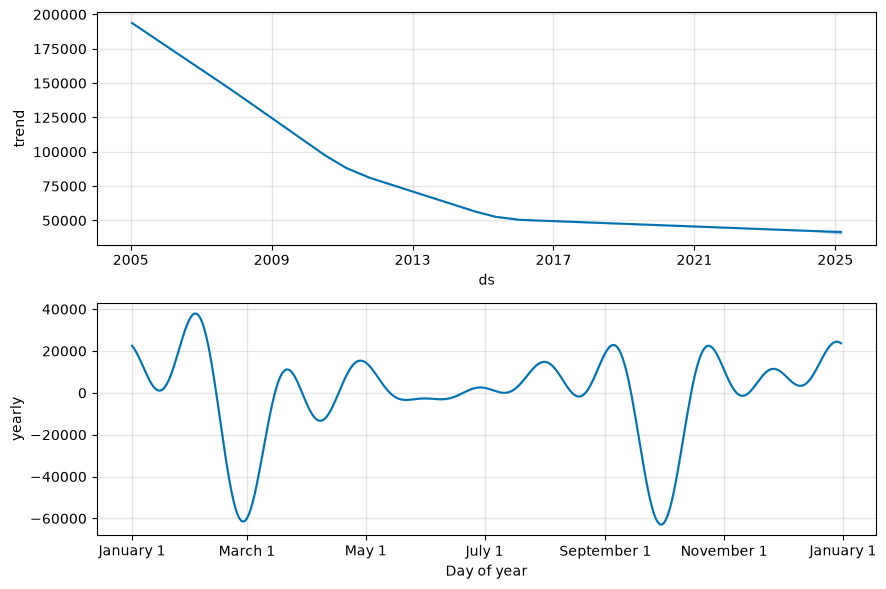

In [34]:
fig = model.plot_components(forecast)

plt.show()

In [35]:
final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.95
)

final_model.fit(prophet_df)

16:26:41 - cmdstanpy - INFO - Chain [1] start processing
16:26:41 - cmdstanpy - INFO - Chain [1] done processing


In [36]:
future = final_model.make_future_dataframe(
    periods=12,
    freq="MS"
)

In [37]:
forecast = final_model.predict(future)

In [38]:
joblib.dump(
    final_model,
    "../models/prophet_model.pkl"
)

print("✅ Final model saved successfully!")

✅ Final model saved successfully!


In [39]:
Prophet(
    changepoint_prior_scale=0.01
)

In [40]:
Prophet(
    yearly_seasonality=10
)

In [41]:
forecast["yhat"] = forecast["yhat"].clip(lower=0)